# Week 4 S3 Results: Conditioning in Code (Monty Hall)

This notebook compares theory vs Monte Carlo estimates for the always-switch strategy in biased Monty Hall.

## Learning goals

1. Understand Monte Carlo as repeated random sampling.
2. Estimate unconditional and conditional probabilities from simulation.
3. See how simulation error shrinks as trial count increases.


## Monte Carlo in one sentence

To estimate probability of an event, simulate many trials and compute:

$$
estimated probability = (number of successes) / (number of trials)
$$

As trials grow, the estimate usually gets closer to the true value.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

repo_root = Path.cwd()
candidate_dirs = [
    repo_root / 'mini_projects' / 'checkpoint_01_conditioning_in_code',
    repo_root,
]
project_dir = next((d for d in candidate_dirs if (d / 'simulate.py').exists()), None)
if project_dir is None:
    raise FileNotFoundError('Could not locate simulate.py from the current working directory.')
if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))

figures_dir = project_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

from simulate import simulate_once, run_grid, theoretical_probabilities


## Warm-up: coin flips

Estimate probability of heads with a fair coin.


In [2]:
rng = np.random.default_rng(4)
n = 20_000
heads = rng.integers(0, 2, size=n)
p_hat = np.mean(heads == 1)
print(f'Estimated P(Heads) = {p_hat:.4f} (theory: 0.5000)')


Estimated P(Heads) = 0.4984 (theory: 0.5000)


## Theory values for biased Monty Hall

For host preference parameter $p$:

- $P(W) = 2/3$
- $P(W \mid D_2) = 1/(1+p)$
- $P(W \mid D_3) = 1/(2-p)$


In [3]:
p = 0.8
th_w, th_d2, th_d3 = theoretical_probabilities(p)
print(f'p = {p:.2f}')
print(f'Theory P(W):    {th_w:.6f}')
print(f'Theory P(W|D2): {th_d2:.6f}')
print(f'Theory P(W|D3): {th_d3:.6f}')

row = simulate_once(p=p, trials=200_000, seed=4)
print('\nSimulation (200,000 trials):')
print(f'P(W):    est={row.est_p_switch_win:.6f}, theory={row.th_p_switch_win:.6f}, abs_err={row.abs_err_switch_win:.6f}')
print(f'P(W|D2): est={row.est_p_switch_win_given_d2:.6f}, theory={row.th_p_switch_win_given_d2:.6f}, abs_err={row.abs_err_switch_win_given_d2:.6f}')
print(f'P(W|D3): est={row.est_p_switch_win_given_d3:.6f}, theory={row.th_p_switch_win_given_d3:.6f}, abs_err={row.abs_err_switch_win_given_d3:.6f}')
print(f'Counts: D2={row.opened_door2_count:,}, D3={row.opened_door3_count:,}')


p = 0.80
Theory P(W):    0.666667
Theory P(W|D2): 0.555556
Theory P(W|D3): 0.833333

Simulation (200,000 trials):
P(W):    est=0.666475, theory=0.666667, abs_err=0.000192
P(W|D2): est=0.556868, theory=0.555556, abs_err=0.001312
P(W|D3): est=0.830910, theory=0.833333, abs_err=0.002423
Counts: D2=120,007, D3=79,993


## Compare multiple p values


In [4]:
p_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rows = run_grid(p_values=p_values, trials=150_000, seed=10)

ps = np.array([r.p for r in rows])
est_w = np.array([r.est_p_switch_win for r in rows])
th_w = np.array([r.th_p_switch_win for r in rows])
est_d2 = np.array([r.est_p_switch_win_given_d2 for r in rows])
th_d2 = np.array([r.th_p_switch_win_given_d2 for r in rows])
est_d3 = np.array([r.est_p_switch_win_given_d3 for r in rows])
th_d3 = np.array([r.th_p_switch_win_given_d3 for r in rows])

for r in rows:
    print(
        f'p={r.p:.2f} | '
        f'P(W) {r.est_p_switch_win:.4f}/{r.th_p_switch_win:.4f} | '
        f'P(W|D2) {r.est_p_switch_win_given_d2:.4f}/{r.th_p_switch_win_given_d2:.4f} | '
        f'P(W|D3) {r.est_p_switch_win_given_d3:.4f}/{r.th_p_switch_win_given_d3:.4f}'
    )


p=0.50 | P(W) 0.6655/0.6667 | P(W|D2) 0.6632/0.6667 | P(W|D3) 0.6678/0.6667
p=0.60 | P(W) 0.6680/0.6667 | P(W|D2) 0.6278/0.6250 | P(W|D3) 0.7140/0.7143
p=0.70 | P(W) 0.6665/0.6667 | P(W|D2) 0.5874/0.5882 | P(W|D3) 0.7700/0.7692
p=0.80 | P(W) 0.6651/0.6667 | P(W|D2) 0.5546/0.5556 | P(W|D3) 0.8313/0.8333
p=0.90 | P(W) 0.6667/0.6667 | P(W|D2) 0.5263/0.5263 | P(W|D3) 0.9093/0.9091
p=1.00 | P(W) 0.6661/0.6667 | P(W|D2) 0.4999/0.5000 | P(W|D3) 1.0000/1.0000


Saved portfolio figure to /Users/juanpineros/juancopi81/diffusion-research-curriculum/mini_projects/checkpoint_01_conditioning_in_code/figures/conditioning_vs_host_bias.png


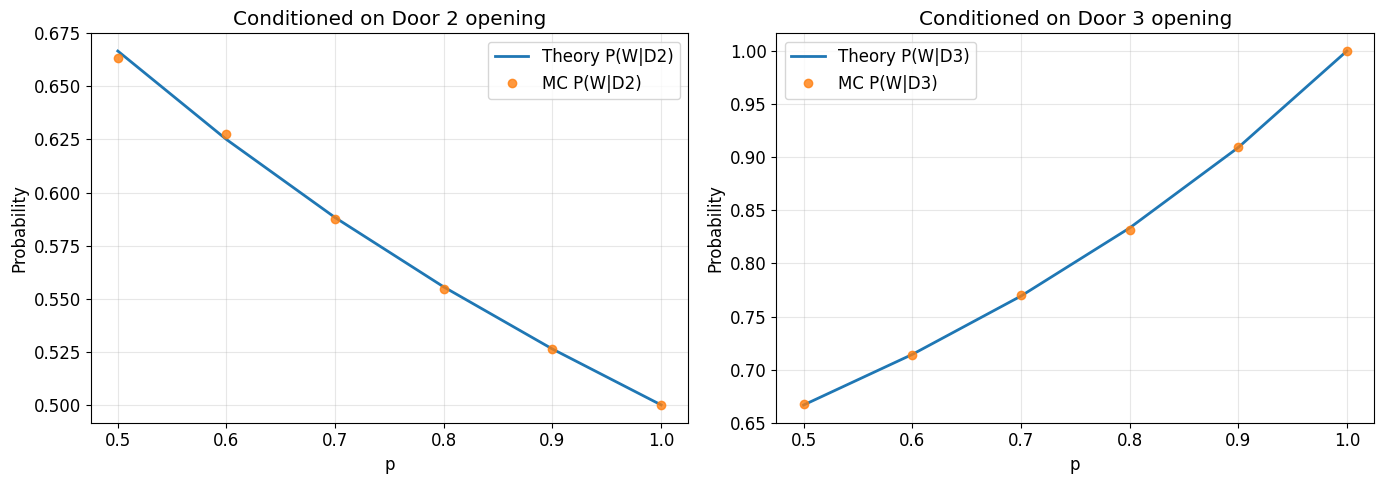

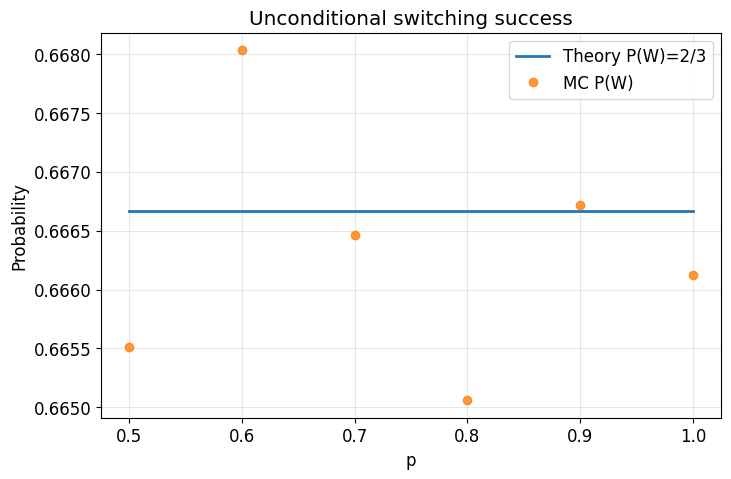

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(ps, th_d2, linewidth=2, label='Theory P(W|D2)')
ax[0].plot(ps, est_d2, 'o', alpha=0.8, label='MC P(W|D2)')
ax[0].set_xlabel('p')
ax[0].set_ylabel('Probability')
ax[0].set_title('Conditioned on Door 2 opening')
ax[0].grid(alpha=0.3)
ax[0].legend()

ax[1].plot(ps, th_d3, linewidth=2, label='Theory P(W|D3)')
ax[1].plot(ps, est_d3, 'o', alpha=0.8, label='MC P(W|D3)')
ax[1].set_xlabel('p')
ax[1].set_ylabel('Probability')
ax[1].set_title('Conditioned on Door 3 opening')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
fig_path = figures_dir / 'conditioning_vs_host_bias.png'
fig.savefig(fig_path, dpi=180, bbox_inches='tight')
print(f'Saved portfolio figure to {fig_path}')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ps, th_w, linewidth=2, label='Theory P(W)=2/3')
plt.plot(ps, est_w, 'o', alpha=0.8, label='MC P(W)')
plt.xlabel('p')
plt.ylabel('Probability')
plt.title('Unconditional switching success')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Convergence check: error vs trial count

As trial count increases, Monte Carlo error should generally shrink.


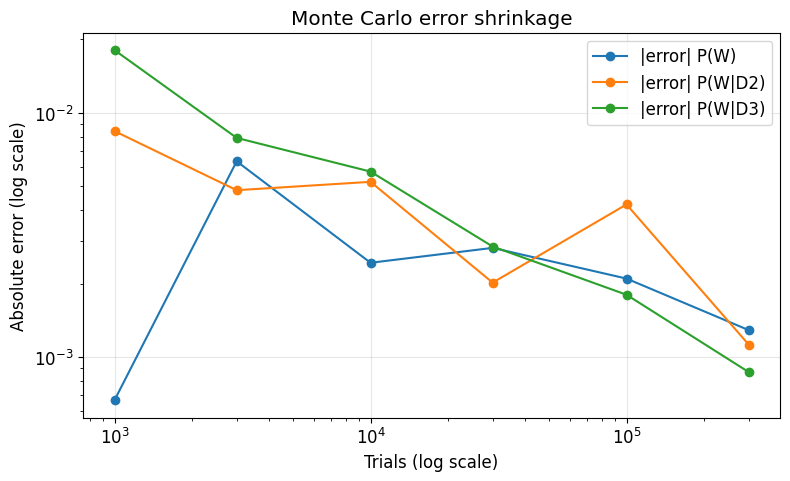

In [6]:
p_fixed = 0.8
trial_grid = [1_000, 3_000, 10_000, 30_000, 100_000, 300_000]

err_w = []
err_d2 = []
err_d3 = []

for i, n_trials in enumerate(trial_grid):
    r = simulate_once(p=p_fixed, trials=n_trials, seed=200 + i)
    err_w.append(r.abs_err_switch_win)
    err_d2.append(r.abs_err_switch_win_given_d2)
    err_d3.append(r.abs_err_switch_win_given_d3)

plt.figure(figsize=(9, 5))
plt.plot(trial_grid, err_w, 'o-', label='|error| P(W)')
plt.plot(trial_grid, err_d2, 'o-', label='|error| P(W|D2)')
plt.plot(trial_grid, err_d3, 'o-', label='|error| P(W|D3)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Trials (log scale)')
plt.ylabel('Absolute error (log scale)')
plt.title('Monte Carlo error shrinkage')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Key observations

1. $P(W)=2/3$ does not change with $p$ because switching wins exactly when the first pick was wrong.
2. $P(W \mid D_2)$ decreases as $p$ increases because Door 2 becomes less informative when Monty already prefers it.
3. $P(W \mid D_3)$ increases as $p$ increases because Door 3 is opened mostly when Monty is forced to reveal it.
4. The Monte Carlo estimates track the theory closely; remaining differences are finite-sample noise.


In [7]:
# Custom sanity run: choose a host bias and large sample size.
my_p = 0.58
my_trials = 1_000_000

custom = simulate_once(p=float(my_p), trials=int(my_trials), seed=999)
print(f'Custom run: p={my_p}, trials={my_trials:,}')
print(f'P(W):    est={custom.est_p_switch_win:.6f}, theory={custom.th_p_switch_win:.6f}')
print(f'P(W|D2): est={custom.est_p_switch_win_given_d2:.6f}, theory={custom.th_p_switch_win_given_d2:.6f}')
print(f'P(W|D3): est={custom.est_p_switch_win_given_d3:.6f}, theory={custom.th_p_switch_win_given_d3:.6f}')


Custom run: p=0.58, trials=1,000,000
P(W):    est=0.666695, theory=0.666667
P(W|D2): est=0.633342, theory=0.632911
P(W|D3): est=0.703838, theory=0.704225


## What I learned

Conditioning is not just filtering data after the fact. It changes the probability model by using the observed event as evidence.
